# SHAP, Control de Overfitting, Calibración y Umbral

## Configuración

In [1]:
import warnings, os, json, itertools, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score,
                                     cross_val_predict, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve, silhouette_score,
                             brier_score_loss)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
import lightgbm as lgb
import shap
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
LGBM_COLOR = 'darkcyan'
def coral(s):  # resaltado coral para valores máximos en prints
    return f'\033[91m{s}\033[0m'

# --- Balanceo heredado del Sprint 2 (LightGBM ganador). Los hiperparámetros se
#     cargan más abajo DIRECTAMENTE del resumen_sprint2.json para no perder precisión. ---
BALANCEO = 'SMOTETomek'
# Fallback de precisión COMPLETA (idéntico a study.best_params del Sprint 2) por si
# no se encuentra el JSON. NO truncar el learning_rate: cambia el F1_CV reproducido.
PARAMS_S2_FALLBACK = {'learning_rate': 0.1287222365527861, 'n_estimators': 167,
                      'num_leaves': 48, 'min_child_samples': 27}

os.makedirs('outputs_sprint3', exist_ok=True)

# --- Carga de datos y split 80/20 estratificado (idéntico a Sprints previos) ---
df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES_BASE = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# --- F1_CV del Sprint 2 (para medir la mejora); fallback al valor reportado ---
try:
    with open('outputs_sprint2/resumen_sprint2.json') as f:
        RES2 = json.load(f)
    F1_SPRINT2 = float(RES2.get('f1_final', 0.754))
except FileNotFoundError:
    RES2 = {}; F1_SPRINT2 = 0.754

# Hiperparámetros del LightGBM ganador: se toman TAL CUAL del resumen del Sprint 2
# (best_params_optuna) para reproducir F1_CV=0.754 sin pérdida de precisión.
PARAMS_S2 = dict(RES2.get('best_params_optuna', PARAMS_S2_FALLBACK))

print(f'Features base: {len(FEATURES_BASE)} | Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Prevalencia positiva (train): {y_train.mean():.3f}')
print(f'Params fijos S2 (LightGBM): {PARAMS_S2} | Balanceo: {BALANCEO}')
print(f'F1_CV Sprint 2 (referencia): {F1_SPRINT2:.4f}')

Features base: 46 | Train: (1705, 46) | Test: (427, 46)
Prevalencia positiva (train): 0.122
Params fijos S2 (LightGBM): {'learning_rate': 0.1287222365527861, 'n_estimators': 167, 'num_leaves': 48, 'min_child_samples': 27} | Balanceo: SMOTETomek
F1_CV Sprint 2 (referencia): 0.7540


## Modelo ganador del Sprint 2

In [2]:
ECONOMICOS = ['Au_ppm', 'Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm']
UMBRAL_CENS = 0.30

df_raw = pd.read_csv('../data/raw/DataSet.csv')
def frac_censurado(col):
    if col not in df_raw.columns:
        return 0.0
    s = df_raw[col].astype(str).str.strip()
    return float(s.str.startswith(('<', '>')).mean())

no_econ_all = [c for c in FEATURES_BASE if c not in ECONOMICOS]
cens = {c: round(frac_censurado(c), 3) for c in no_econ_all}
NO_ECON = [c for c in no_econ_all if cens[c] <= UMBRAL_CENS]
print(f'No económicos válidos para FE: {len(NO_ECON)} (de {len(no_econ_all)})')

No económicos válidos para FE: 39 (de 42)


In [3]:
# Log-transformación de base asimétrica
sk = X_train.apply(lambda c: skew(c.dropna()))
ASIM = sk[sk > 1.5].index.tolist()
X_train_logbase = X_train.copy(); X_test_logbase = X_test.copy()
for c in ASIM:
    X_train_logbase[c] = np.log1p(X_train[c].clip(lower=0))
    X_test_logbase[c]  = np.log1p(X_test[c].clip(lower=0))
print(f'Base asimétrica log-transformada: {len(ASIM)} features')

# Log-ratios exhaustivos (una dirección) entre no económicos
EPS = 1e-9
pares = list(itertools.combinations(NO_ECON, 2))
def construir_ratios(Xsrc):
    d = {f'{a}__over__{b}': np.log(Xsrc[a].clip(lower=EPS) / Xsrc[b].clip(lower=EPS))
         for a, b in pares}
    return pd.DataFrame(d, index=Xsrc.index)
R_train = construir_ratios(X_train).replace([np.inf, -np.inf], np.nan)
R_test  = construir_ratios(X_test).replace([np.inf, -np.inf], np.nan)
med_r = R_train.median()
R_train = R_train.fillna(med_r); R_test = R_test.fillna(med_r)
print(f'Log-ratios creados: {R_train.shape[1]}')

# Filtro de correlación |r|>0.95
UMBRAL_CORR = 0.95
corr_abs = R_train.corr().abs()
triu = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
drop_corr = [col for col in triu.columns if (triu[col] > UMBRAL_CORR).any()]
R_train_c = R_train.drop(columns=drop_corr); R_test_c = R_test.drop(columns=drop_corr)
print(f'Ratios tras correlación: {R_train_c.shape[1]}')

# Reducción por VIF<10 (iterativo)
UMBRAL_VIF = 10.0
def vif_iterativo(dframe, umbral=UMBRAL_VIF, max_iter=1000):
    cols = list(dframe.columns)
    for _ in range(max_iter):
        if len(cols) <= 1:
            break
        C = dframe[cols].corr().values
        try:
            inv = np.linalg.inv(C)
        except np.linalg.LinAlgError:
            inv = np.linalg.pinv(C)
        vifs = np.diag(inv)
        imax = int(np.argmax(vifs)); vmax = float(vifs[imax])
        if vmax > umbral:
            cols.pop(imax)
        else:
            break
    return cols
t0 = time.time()
RATIOS_SEL = vif_iterativo(R_train_c)
print(f'Ratios finales (VIF<{UMBRAL_VIF}): {len(RATIOS_SEL)}  ({time.time()-t0:.0f}s)')

Base asimétrica log-transformada: 30 features
Log-ratios creados: 741
Ratios tras correlación: 555
Ratios finales (VIF<10.0): 93  (219s)


In [4]:
def features_cluster(Xtr_esp, Xte_esp, etiqueta):
    '''5 features de cluster (KMeans+GMM+DBSCAN) en el espacio dado.'''
    sc = StandardScaler().fit(Xtr_esp)
    Ztr, Zte = sc.transform(Xtr_esp), sc.transform(Xte_esp)
    sils = [silhouette_score(Ztr, KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(Ztr))
            for k in range(2, 11)]
    k_km = int(np.argmax(sils)) + 2
    km = KMeans(n_clusters=k_km, random_state=SEED, n_init=10).fit(Ztr)
    bics = [GaussianMixture(n_components=k, random_state=SEED).fit(Ztr).bic(Ztr) for k in range(2, 11)]
    k_gmm = int(np.argmin(bics)) + 2
    gm = GaussianMixture(n_components=k_gmm, random_state=SEED).fit(Ztr)
    nn = NearestNeighbors(n_neighbors=10).fit(Ztr)
    kdist = np.sort(nn.kneighbors(Ztr)[0][:, -1])
    eps = float(np.percentile(kdist, 90))
    db_tr = DBSCAN(eps=eps, min_samples=10).fit_predict(Ztr)
    db_te = DBSCAN(eps=eps, min_samples=10).fit_predict(Zte)
    def dist_centroides(Z):
        return np.min(np.linalg.norm(Z[:, None, :] - km.cluster_centers_[None, :, :], axis=2), axis=1)
    ftr = pd.DataFrame({
        f'kmeans_label_{etiqueta}': km.labels_,
        f'kmeans_dist_{etiqueta}': dist_centroides(Ztr),
        f'gmm_label_{etiqueta}': gm.predict(Ztr),
        f'gmm_prob_max_{etiqueta}': gm.predict_proba(Ztr).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_tr == -1).astype(int),
    }, index=Xtr_esp.index)
    fte = pd.DataFrame({
        f'kmeans_label_{etiqueta}': km.predict(Zte),
        f'kmeans_dist_{etiqueta}': dist_centroides(Zte),
        f'gmm_label_{etiqueta}': gm.predict(Zte),
        f'gmm_prob_max_{etiqueta}': gm.predict_proba(Zte).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_te == -1).astype(int),
    }, index=Xte_esp.index)
    return ftr, fte

# Clustering en espacio LOG (el ganador del Sprint 2)
Xtr_log = np.log1p(X_train[NO_ECON].clip(lower=0))
Xte_log = np.log1p(X_test[NO_ECON].clip(lower=0))
cl_log_tr, cl_log_te = features_cluster(Xtr_log, Xte_log, 'log')
print(f'Features de clustering LOG: {list(cl_log_tr.columns)}')

Features de clustering LOG: ['kmeans_label_log', 'kmeans_dist_log', 'gmm_label_log', 'gmm_prob_max_log', 'dbscan_outlier_log']


In [5]:
# set_S2 = E5 + FE + Cluster LOG (idéntico al ganador del Sprint 2)
X_S2_tr = pd.concat([X_train_logbase, R_train_c[RATIOS_SEL], cl_log_tr], axis=1)
X_S2_te = pd.concat([X_test_logbase,  R_test_c[RATIOS_SEL],  cl_log_te], axis=1)
FEATURES_S2 = list(X_S2_tr.columns)
print(f'set E5 (S2): {len(FEATURES_S2)} features '
      f'= {len(FEATURES_BASE)} base + {len(RATIOS_SEL)} ratios + {cl_log_tr.shape[1]} clustering')

# --- Helper F1_CV para LightGBM (SMOTETomek DENTRO de cada fold) ---
def make_pipe(params):
    return ImbPipeline([
        ('sc', StandardScaler()),
        ('bal', SMOTETomek(random_state=SEED)),
        ('clf', lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, n_jobs=-1)),
    ])

def f1_cv_lgbm(Xin, ytr, params, features=None):
    '''MÉTRICA PRIMARIA: F1 clase positiva por CV 5-fold. Devuelve (media, std).'''
    Xuse = Xin[features] if features is not None else Xin
    sc = cross_val_score(make_pipe(params), Xuse, ytr, cv=CV5, scoring='f1', n_jobs=-1)
    return sc.mean(), sc.std()

# Verificación: reproducir F1_CV del Sprint 2 sobre el set completo.
# El pipeline es IDÉNTICO al del Sprint 2 (StandardScaler -> SMOTETomek -> LightGBM),
# con las MISMAS 144 features y los MISMOS best_params_optuna: en la misma máquina
# el F1_CV reproducido debe coincidir con el del Sprint 2 (0.754).
f1_s2_check, sd_s2_check = f1_cv_lgbm(X_S2_tr, y_train, PARAMS_S2)
delta = f1_s2_check - F1_SPRINT2
print(f'F1_CV reproducido (144 features, params S2): {f1_s2_check:.4f} ± {sd_s2_check:.4f}')
print(f'F1_CV Sprint 2 (referencia): {F1_SPRINT2:.4f}  |  Δ = {delta:+.4f}')
if abs(delta) <= 0.002:
    print(coral('OK: reproducción exacta del Sprint 2 (Δ<=0.002).'))
else:
    print(f'Nota: Δ={delta:+.4f}. Si es >0.002, revisar versión de LightGBM / nº de hilos '
          f'(el binning por histograma puede variar entre entornos).')

set E5 (S2): 144 features = 46 base + 93 ratios + 5 clustering
F1_CV reproducido (144 features, params S2): 0.7540 ± 0.0382
F1_CV Sprint 2 (referencia): 0.7540  |  Δ = -0.0000
OK: reproducción exacta del Sprint 2 (Δ<=0.002).


## SHAP

In [6]:
# Modelo S2 para SHAP: SMOTETomek sobre el training set completo (trees invariantes a escala)
Xtr_res, ytr_res = SMOTETomek(random_state=SEED).fit_resample(X_S2_tr, y_train)
clf_shap = lgb.LGBMClassifier(**PARAMS_S2, random_state=SEED, verbose=-1, n_jobs=-1)
clf_shap.fit(Xtr_res, ytr_res)

# SHAP sobre el training set (distribución real, no la remuestreada)
explainer = shap.TreeExplainer(clf_shap)
sv = explainer.shap_values(X_S2_tr)
if isinstance(sv, list):        # compatibilidad: algunas versiones devuelven [clase0, clase1]
    sv = sv[1]
sv = np.asarray(sv)
ev = explainer.expected_value
base_val = float(np.asarray(ev).ravel()[-1]) if np.ndim(ev) else float(ev)

# Importancia = media del |SHAP| por feature
imp = np.abs(sv).mean(axis=0)
imp_ser = pd.Series(imp, index=FEATURES_S2).sort_values(ascending=False)
imp_df = imp_ser.reset_index(); imp_df.columns = ['feature', 'mean_abs_shap']
imp_df['cum_frac'] = imp_df['mean_abs_shap'].cumsum() / imp_df['mean_abs_shap'].sum()
imp_df.to_csv('outputs_sprint3/shap_importancias.csv', index=False)
print(f'SHAP calculado sobre {X_S2_tr.shape[0]} muestras × {X_S2_tr.shape[1]} features')
print(imp_df.head(15).to_string(index=False))

SHAP calculado sobre 1705 muestras × 144 features
             feature  mean_abs_shap  cum_frac
              Ag_ppm       6.451571  0.293229
              Te_ppm       0.963774  0.337033
              Se_ppm       0.787476  0.372825
              Sb_ppm       0.664114  0.403009
Cr_ppm__over__Mg_per       0.589916  0.429822
Ba_ppm__over__Sb_ppm       0.556116  0.455097
Be_ppm__over__Zr_ppm       0.476668  0.476762
Mn_ppm__over__Sb_ppm       0.427544  0.496195
     kmeans_dist_log       0.344833  0.511868
Al_per__over__Sc_ppm       0.285996  0.524866
Ce_ppm__over__Fe_per       0.281984  0.537683
Fe_per__over__Sn_ppm       0.271893  0.550040
Al_per__over__Th_ppm       0.256426  0.561695
Ba_ppm__over__Na_per       0.248766  0.573002
              La_ppm       0.246966  0.584227


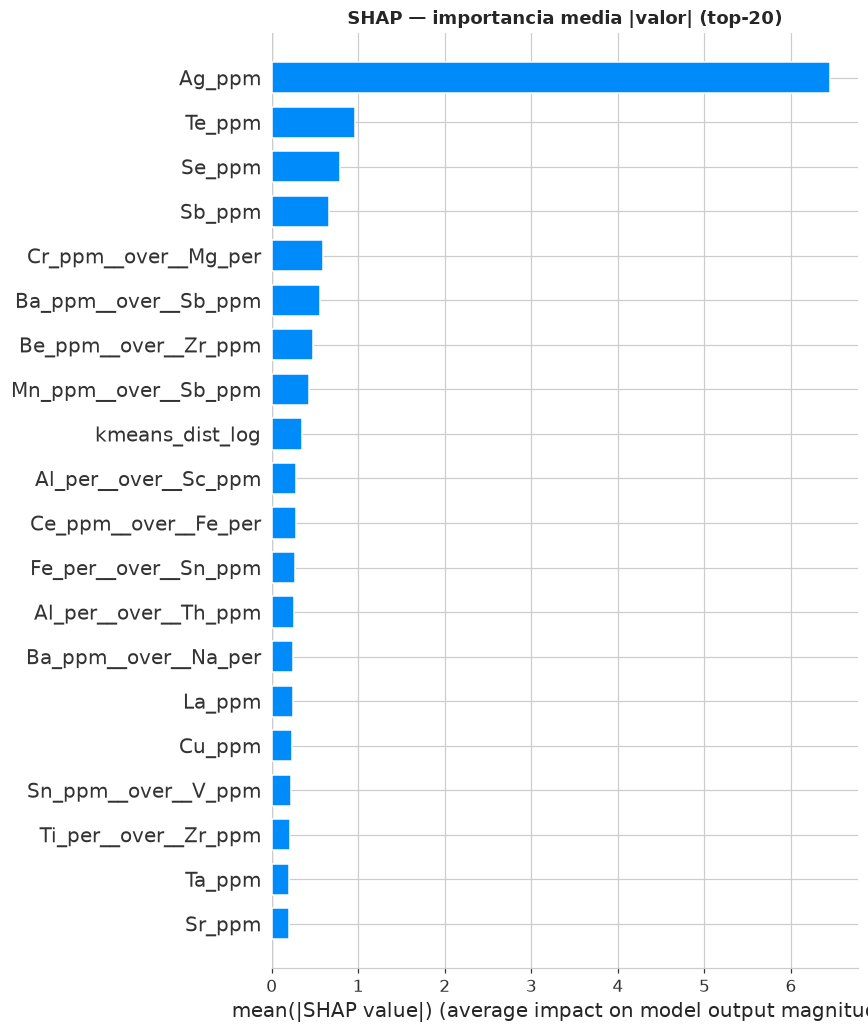

In [7]:
# (1) Bar plot — importancia media |SHAP|
plt.figure()
shap.summary_plot(sv, X_S2_tr, plot_type='bar', max_display=20, show=False)
plt.title('SHAP — importancia media |valor| (top-20)', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint3/shap_bar.png', bbox_inches='tight'); plt.show()

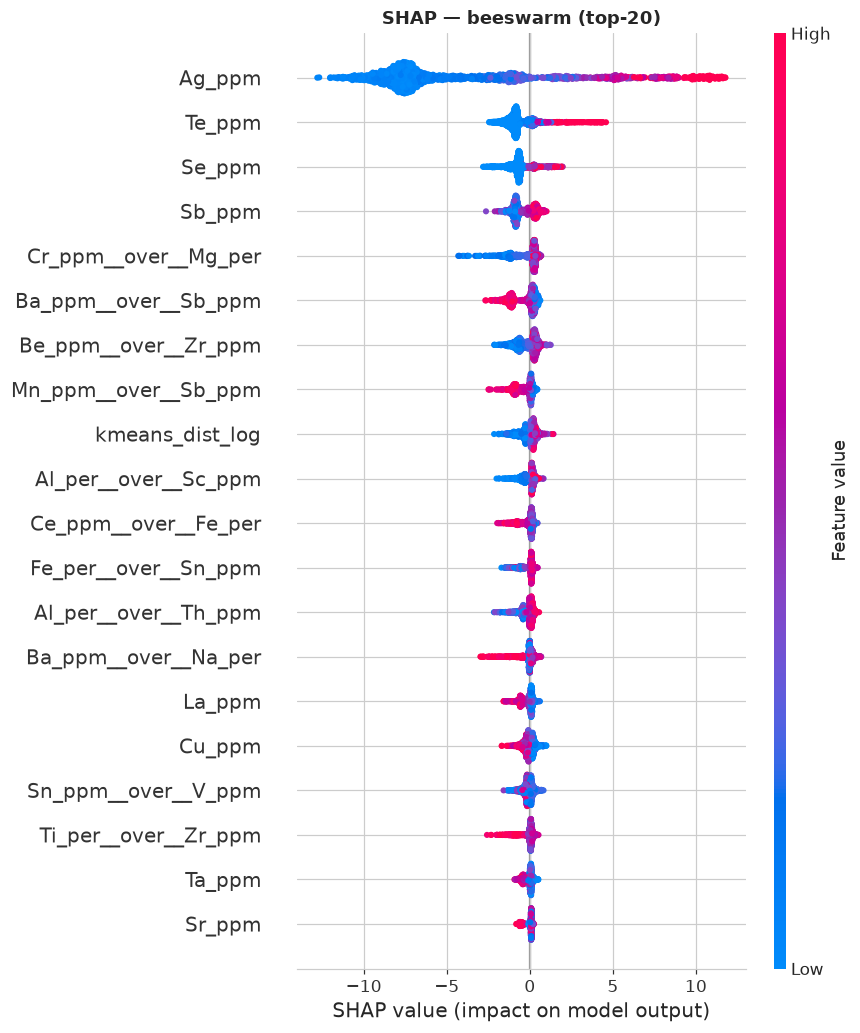

In [8]:
# (2) Beeswarm — distribución de contribuciones
plt.figure()
shap.summary_plot(sv, X_S2_tr, max_display=20, show=False)
plt.title('SHAP — beeswarm (top-20)', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint3/shap_beeswarm.png', bbox_inches='tight'); plt.show()

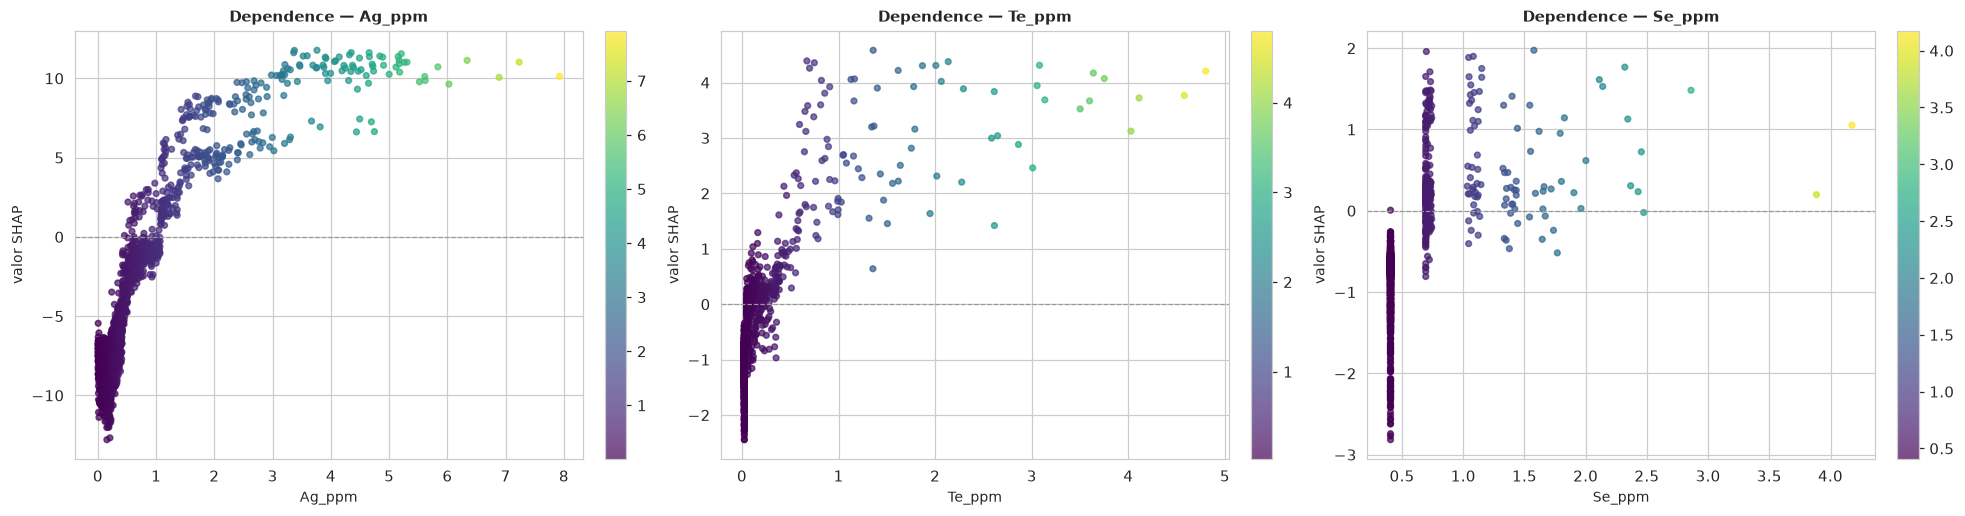

Top-3 por SHAP: ['Ag_ppm', 'Te_ppm', 'Se_ppm']


In [9]:
# (3) Dependence de las 3 features más importantes (una sola imagen).
# Scatter manual (valor de la feature vs su SHAP) en vez de shap.dependence_plot:
# el parámetro ax= de shap.dependence_plot es inestable entre versiones de SHAP.
top3 = imp_ser.index[:3].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for i, feat in enumerate(top3):
    j = FEATURES_S2.index(feat)          # columna de esta feature en sv y en X_S2_tr
    xvals = X_S2_tr[feat].values
    yvals = sv[:, j]
    sc = axes[i].scatter(xvals, yvals, c=xvals, cmap='viridis', s=14, alpha=0.7)
    axes[i].axhline(0, color='0.6', lw=0.8, ls='--')
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('valor SHAP', fontsize=9)
    axes[i].set_title(f'Dependence — {feat}', fontweight='bold', fontsize=10)
    fig.colorbar(sc, ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.savefig('outputs_sprint3/shap_dependence_top3.png', bbox_inches='tight'); plt.show()
print(f'Top-3 por SHAP: {top3}')

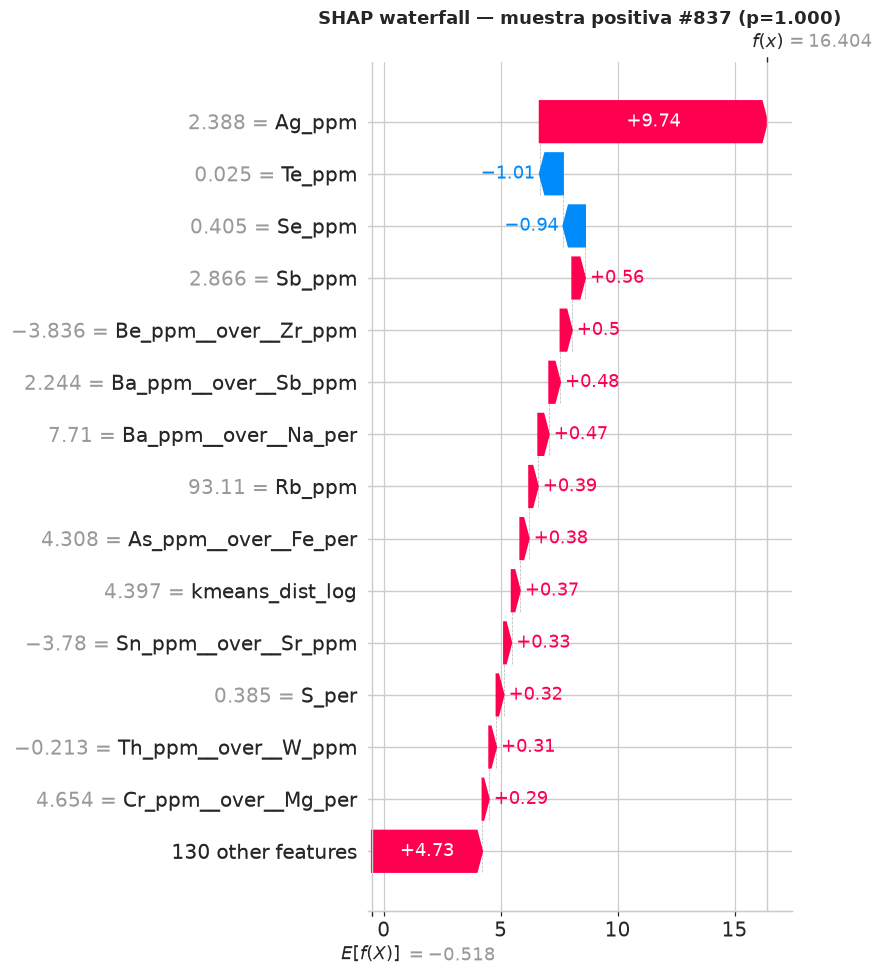

In [10]:
# (4) Waterfall de un ejemplo positivo bien puntuado
proba_tr = clf_shap.predict_proba(X_S2_tr)[:, 1]
mask_pos = (y_train.values == 1)
idx_ej = int(np.where(mask_pos)[0][np.argmax(proba_tr[mask_pos])])
expl = shap.Explanation(values=sv[idx_ej], base_values=base_val,
                        data=X_S2_tr.iloc[idx_ej].values, feature_names=FEATURES_S2)
plt.figure()
shap.plots.waterfall(expl, max_display=15, show=False)
plt.title(f'SHAP waterfall — muestra positiva #{idx_ej} (p={proba_tr[idx_ej]:.3f})', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint3/shap_waterfall.png', bbox_inches='tight'); plt.show()

## Selección de features

Features que acumulan el 95% de |SHAP|: 101 de 144


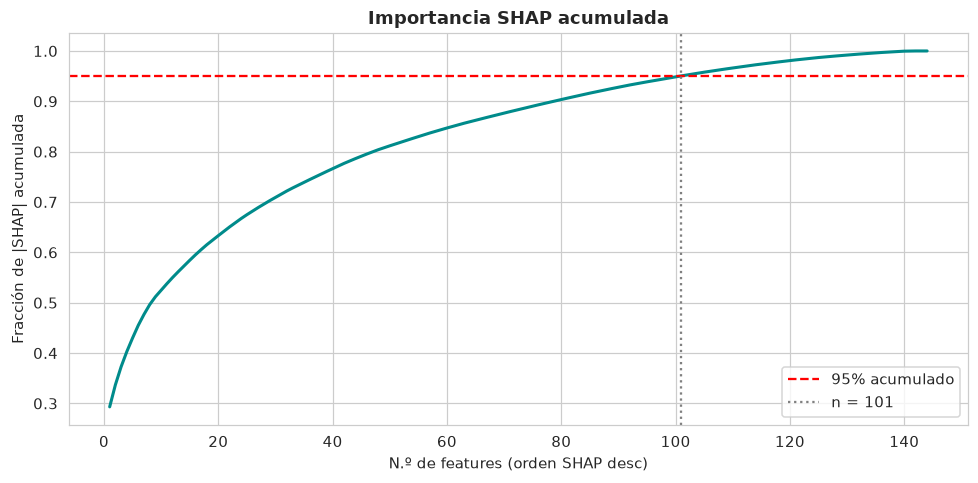

In [11]:
UMBRAL_ACUM = 0.95
n_95 = int(np.searchsorted(imp_df['cum_frac'].values, UMBRAL_ACUM) + 1)
n_95 = min(n_95, len(FEATURES_S2))
feats_95 = imp_df['feature'].iloc[:n_95].tolist()   # ordenadas por importancia SHAP desc
print(f'Features que acumulan el {int(UMBRAL_ACUM*100)}% de |SHAP|: {n_95} de {len(FEATURES_S2)}')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, len(imp_df)+1), imp_df['cum_frac'].values, color=LGBM_COLOR, lw=2)
ax.axhline(UMBRAL_ACUM, ls='--', color='red', label=f'{int(UMBRAL_ACUM*100)}% acumulado')
ax.axvline(n_95, ls=':', color='gray', label=f'n = {n_95}')
ax.set_xlabel('N.º de features (orden SHAP desc)'); ax.set_ylabel('Fracción de |SHAP| acumulada')
ax.set_title('Importancia SHAP acumulada', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig('outputs_sprint3/shap_acumulada.png', bbox_inches='tight'); plt.show()

In [ ]:
print(f'Barrido CV sobre {n_95} subconjuntos (top-1 … top-{n_95}) ...')
t0 = time.time()
rows = []
for k in range(1, n_95 + 1):
    mu, sd = f1_cv_lgbm(X_S2_tr, y_train, PARAMS_S2, features=feats_95[:k])
    rows.append({'n_features': k, 'f1_cv_mean': mu, 'f1_cv_std': sd})
sweep = pd.DataFrame(rows)
sweep.to_csv('outputs_sprint3/seleccion_1se.csv', index=False)
print(f'Barrido terminado en {time.time()-t0:.0f}s')

# Regla 1-SE
k_best = int(sweep['f1_cv_mean'].idxmax())
f1_best = float(sweep['f1_cv_mean'].iloc[k_best])
se_best = float(sweep['f1_cv_std'].iloc[k_best]) / np.sqrt(5)
umbral_1se = f1_best - se_best
elegibles = sweep[sweep['f1_cv_mean'] >= umbral_1se]
n_opt = int(elegibles['n_features'].min())
set_S3 = feats_95[:n_opt]
f1_s3_fijo = float(sweep.loc[sweep['n_features'] == n_opt, 'f1_cv_mean'].iloc[0])

print(f'Mejor F1_CV: {coral(f"{f1_best:.4f}")} con {sweep["n_features"].iloc[k_best]} features '
      f'(SE={se_best:.4f}, umbral 1-SE={umbral_1se:.4f})')
print(f'n_opt (regla 1-SE): {n_opt} features → F1_CV={f1_s3_fijo:.4f}')

Barrido CV sobre 101 subconjuntos (top-1 … top-101) ...
Barrido terminado en 1138s
Mejor F1_CV: 0.7634 con 47 features (SE=0.0134, umbral 1-SE=0.7500)
★ n_opt (regla 1-SE): 47 features → F1_CV=0.7634


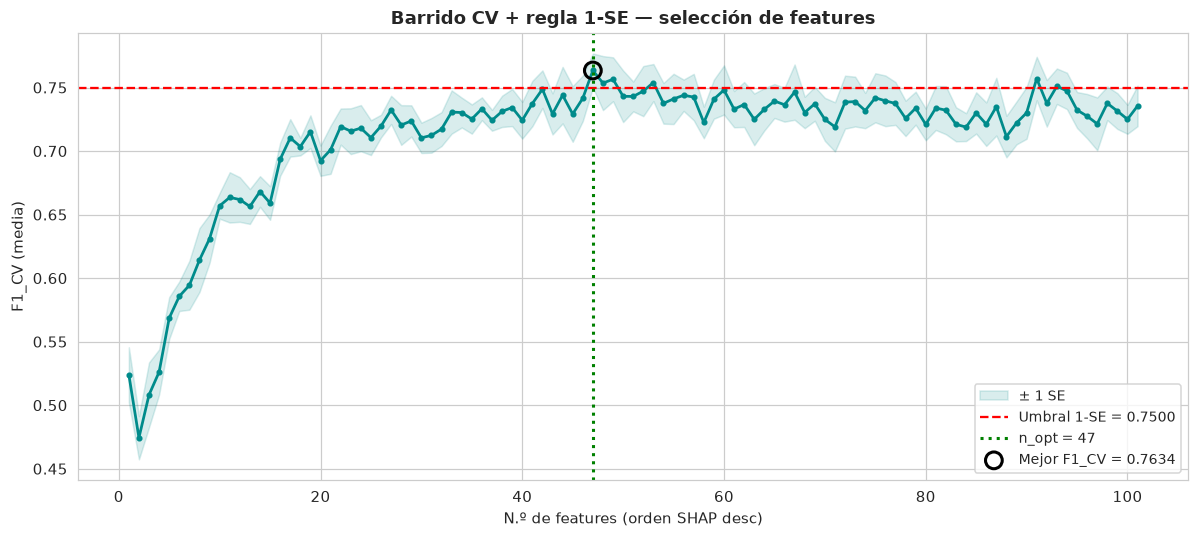

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sweep['n_features'], sweep['f1_cv_mean'], color=LGBM_COLOR, lw=1.8, marker='o', markersize=3)
ax.fill_between(sweep['n_features'],
                sweep['f1_cv_mean'] - sweep['f1_cv_std']/np.sqrt(5),
                sweep['f1_cv_mean'] + sweep['f1_cv_std']/np.sqrt(5),
                color=LGBM_COLOR, alpha=0.15, label='± 1 SE')
ax.axhline(umbral_1se, ls='--', color='red', label=f'Umbral 1-SE = {umbral_1se:.4f}')
ax.axvline(n_opt, ls=':', color='green', lw=2, label=f'n_opt = {n_opt}')
ax.scatter([sweep['n_features'].iloc[k_best]], [f1_best], s=120, facecolors='none',
           edgecolors='black', linewidths=2, zorder=5, label=f'Mejor F1_CV = {f1_best:.4f}')
ax.set_xlabel('N.º de features (orden SHAP desc)'); ax.set_ylabel('F1_CV (media)')
ax.set_title('Barrido CV + regla 1-SE — selección de features', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('outputs_sprint3/seleccion_1se.png', bbox_inches='tight'); plt.show()

## Curvas de aprendizaje (control de overfitting)

In [14]:
X_S3_tr = X_S2_tr[set_S3].copy()
X_S3_te = X_S2_te[set_S3].copy()

train_sizes = np.linspace(0.1, 1.0, 8)
sizes, tr_sc, va_sc = learning_curve(
    make_pipe(PARAMS_S2), X_S3_tr, y_train, cv=CV5, scoring='f1',
    train_sizes=train_sizes, n_jobs=-1, shuffle=True, random_state=SEED)
tr_mean, tr_std = tr_sc.mean(1), tr_sc.std(1)
va_mean, va_std = va_sc.mean(1), va_sc.std(1)
gap = tr_mean - va_mean

gap_df = pd.DataFrame({'train_size': sizes.astype(int),
                       'f1_train': tr_mean.round(4), 'f1_val': va_mean.round(4),
                       'gap': gap.round(4)})
gap_df.to_csv('outputs_sprint3/gap_s3_params_fijos.csv', index=False)
print(gap_df.to_string(index=False))
print(f'\nBrecha final (train-val) al 100%: {gap[-1]:.4f}')

 train_size  f1_train  f1_val    gap
        136    1.0000  0.5673 0.4327
        311    1.0000  0.6259 0.3741
        487    1.0000  0.6799 0.3201
        662    1.0000  0.6697 0.3303
        837    0.9980  0.7176 0.2804
       1013    0.9992  0.7384 0.2608
       1188    1.0000  0.7381 0.2619
       1364    1.0000  0.7447 0.2553

Brecha final (train-val) al 100%: 0.2553


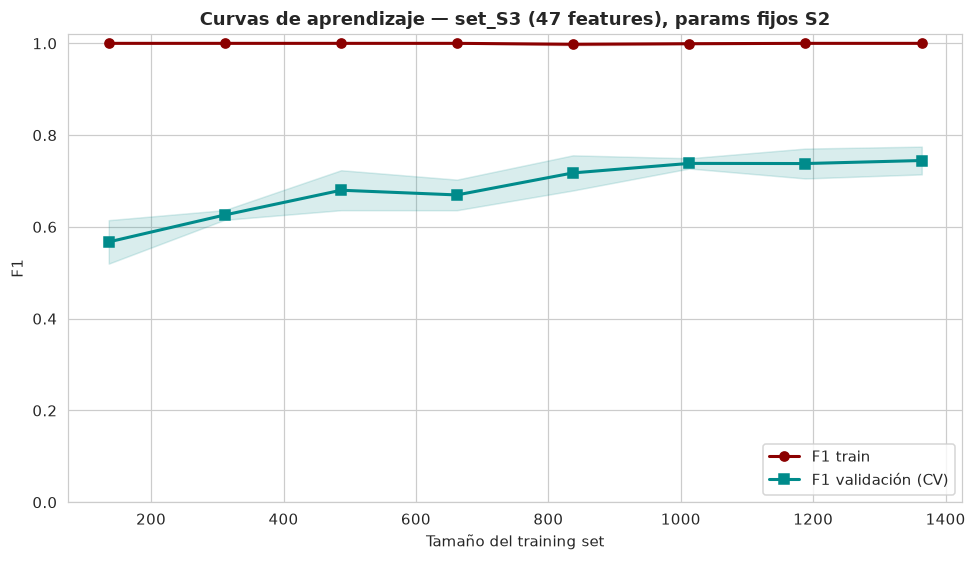

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(sizes, tr_mean, marker='o', color='darkred', lw=2, label='F1 train')
ax.fill_between(sizes, tr_mean-tr_std, tr_mean+tr_std, color='darkred', alpha=0.12)
ax.plot(sizes, va_mean, marker='s', color=LGBM_COLOR, lw=2, label='F1 validación (CV)')
ax.fill_between(sizes, va_mean-va_std, va_mean+va_std, color=LGBM_COLOR, alpha=0.15)
ax.set_xlabel('Tamaño del training set'); ax.set_ylabel('F1'); ax.set_ylim(0, 1.02)
ax.set_title(f'Curvas de aprendizaje — set_S3 ({len(set_S3)} features), params fijos S2',
             fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint3/learning_curves_s3.png', bbox_inches='tight'); plt.show()

## Re-Optuna

In [16]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 80, 300),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 63),
        'learning_rate':    trial.suggest_float('learning_rate', 0.03, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 40),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.0, 1.0),
        'subsample_freq':   1,   # habilita el submuestreo por filas (subsample surte efecto)
    }
    mu, _ = f1_cv_lgbm(X_S3_tr, y_train, params)
    return mu

print(f'Re-Optuna LightGBM sobre set_S3 ({len(set_S3)} features), 100 trials ...')
t0 = time.time()
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=100, n_jobs=1, show_progress_bar=False)
print(f'Optuna terminado en {time.time()-t0:.0f}s')

# Comparación con los params fijos S2 (decisión por F1_CV)
f1_opt = float(study.best_value)
if f1_opt >= f1_s3_fijo:
    PARAMS_S3 = {**study.best_params, 'subsample_freq': 1}
    f1_s3 = f1_opt; origen_params = 'Optuna S3'
else:
    PARAMS_S3 = dict(PARAMS_S2)
    f1_s3 = f1_s3_fijo; origen_params = 'Fijos S2 (Optuna no mejoró)'

with open('outputs_sprint3/optuna_s3_best_params.json', 'w') as f:
    json.dump({'best_params': study.best_params, 'f1_cv_optuna': round(f1_opt, 4),
               'f1_cv_params_fijos_s2': round(f1_s3_fijo, 4), 'params_elegidos': PARAMS_S3,
               'origen': origen_params}, f, indent=2, ensure_ascii=False)

print(f'F1_CV Optuna S3: {coral(f"{f1_opt:.4f}")} | F1_CV fijos S2 (set_S3): {f1_s3_fijo:.4f}')
print(f'Params elegidos ({origen_params}): {PARAMS_S3}')

Re-Optuna LightGBM sobre set_S3 (47 features), 100 trials ...
Optuna terminado en 1044s
F1_CV Optuna S3: 0.7706 | F1_CV fijos S2 (set_S3): 0.7634
Params elegidos (Optuna S3): {'n_estimators': 232, 'num_leaves': 59, 'learning_rate': 0.04415508827314991, 'subsample': 0.7316763198578394, 'colsample_bytree': 0.9539086384084597, 'min_child_samples': 11, 'reg_lambda': 0.8960901541288493, 'subsample_freq': 1}


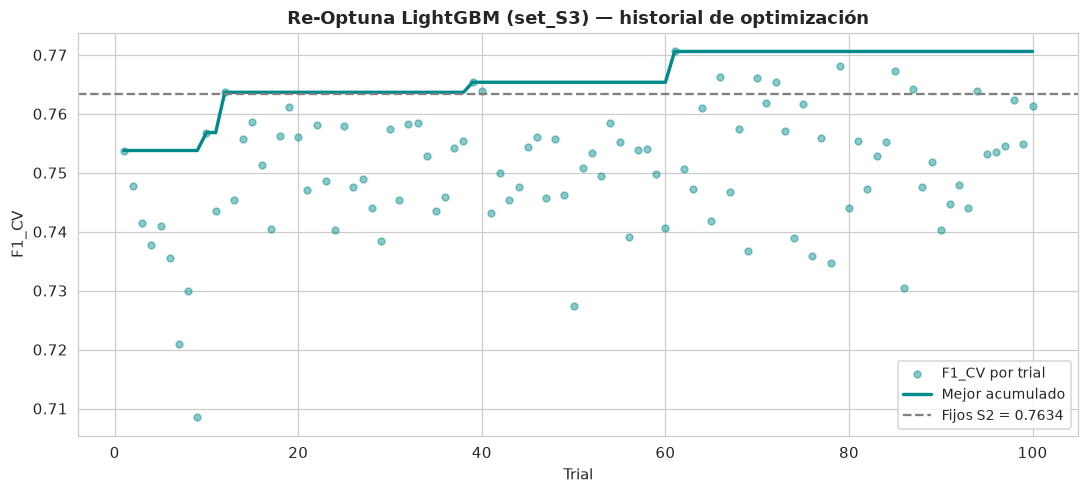

In [17]:
# Historial de optimización
vals = [t.value for t in study.trials if t.value is not None]
best_run = np.maximum.accumulate(vals)
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.scatter(range(1, len(vals)+1), vals, s=20, alpha=0.45, color=LGBM_COLOR, label='F1_CV por trial')
ax.plot(range(1, len(vals)+1), best_run, lw=2.2, color=LGBM_COLOR, label='Mejor acumulado')
ax.axhline(f1_s3_fijo, ls='--', color='gray', label=f'Fijos S2 = {f1_s3_fijo:.4f}')
ax.set_xlabel('Trial'); ax.set_ylabel('F1_CV')
ax.set_title('Re-Optuna LightGBM (set_S3) — historial de optimización', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint3/optuna_s3_history.png', bbox_inches='tight'); plt.show()

## Calibración Post-Optimización

In [18]:
sizes3, tr_sc3, va_sc3 = learning_curve(
    make_pipe(PARAMS_S3), X_S3_tr, y_train, cv=CV5, scoring='f1',
    train_sizes=train_sizes, n_jobs=-1, shuffle=True, random_state=SEED)
tr_mean3, tr_std3 = tr_sc3.mean(1), tr_sc3.std(1)
va_mean3, va_std3 = va_sc3.mean(1), va_sc3.std(1)
gap3 = tr_mean3 - va_mean3

gap_df3 = pd.DataFrame({'train_size': sizes3.astype(int),
                        'f1_train': tr_mean3.round(4), 'f1_val': va_mean3.round(4),
                        'gap': gap3.round(4)})
gap_df3.to_csv('outputs_sprint3/gap_s3_params_optuna.csv', index=False)
print(gap_df3.to_string(index=False))

gap_pre, gap_post = float(gap[-1]), float(gap3[-1])
delta_gap = gap_pre - gap_post
print(f'\nBrecha final (train-val) al 100%:')
print(f'  Paso 2  (params fijos S2)  : {gap_pre:.4f}')
print(f'  Paso 3b (params Optuna S3) : {gap_post:.4f}')
if delta_gap > 0:
    print(f'  -> La re-optimización REDUJO la brecha en {coral(f"{delta_gap:.4f}")} (mejor control de varianza).')
elif delta_gap < 0:
    print(f'  -> La brecha AUMENTÓ en {abs(delta_gap):.4f}; la mejora de Optuna vino por mayor F1 de validación, no por menor gap.')
else:
    print(f'  -> La brecha se mantuvo igual.')

 train_size  f1_train  f1_val    gap
        136    1.0000  0.6037 0.3963
        311    1.0000  0.6356 0.3644
        487    1.0000  0.6771 0.3229
        662    1.0000  0.6994 0.3006
        837    0.9980  0.7106 0.2874
       1013    0.9992  0.7517 0.2475
       1188    1.0000  0.7363 0.2637
       1364    1.0000  0.7278 0.2722

Brecha final (train-val) al 100%:
  Paso 2  (params fijos S2)  : 0.2553
  Paso 3b (params Optuna S3) : 0.2722
  -> La brecha AUMENTÓ en 0.0169; la mejora de Optuna vino por mayor F1 de validación, no por menor gap.


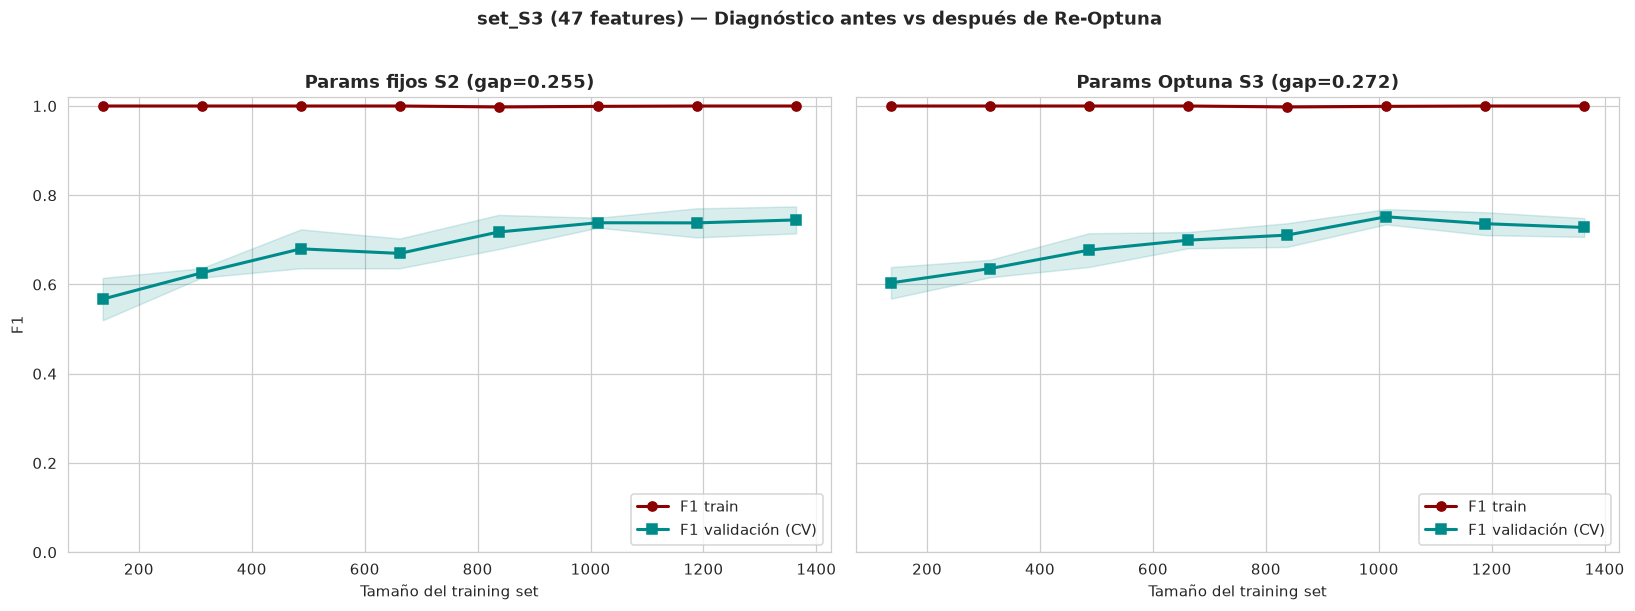

In [19]:
# Comparación visual: fijos S2 vs Optuna S3
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), sharey=True)
for ax, (s, trm, trs, vam, vas, g, tit) in zip(axes, [
        (sizes,  tr_mean,  tr_std,  va_mean,  va_std,  gap,  f'Params fijos S2 (gap={gap_pre:.3f})'),
        (sizes3, tr_mean3, tr_std3, va_mean3, va_std3, gap3, f'Params Optuna S3 (gap={gap_post:.3f})')]):
    ax.plot(s, trm, marker='o', color='darkred', lw=2, label='F1 train')
    ax.fill_between(s, trm-trs, trm+trs, color='darkred', alpha=0.12)
    ax.plot(s, vam, marker='s', color=LGBM_COLOR, lw=2, label='F1 validación (CV)')
    ax.fill_between(s, vam-vas, vam+vas, color=LGBM_COLOR, alpha=0.15)
    ax.set_xlabel('Tamaño del training set'); ax.set_ylim(0, 1.02)
    ax.set_title(tit, fontweight='bold'); ax.legend(loc='lower right')
axes[0].set_ylabel('F1')
plt.suptitle(f'set_S3 ({len(set_S3)} features) — Diagnóstico antes vs después de Re-Optuna',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs_sprint3/learning_curves_s3_comparacion.png', bbox_inches='tight'); plt.show()

## Calibración y ajuste de umbral

In [20]:
def oof_proba(factory, X, yv):
    '''Probabilidades OOF: se entrena en cada fold de train y se predice el fold de validación.'''
    oof = np.zeros(len(yv), dtype=float)
    for tr_idx, va_idx in CV5.split(X, yv):
        est = factory()
        est.fit(X.iloc[tr_idx], yv.iloc[tr_idx])
        oof[va_idx] = est.predict_proba(X.iloc[va_idx])[:, 1]
    return oof

fac_uncal = lambda: make_pipe(PARAMS_S3)
fac_sig   = lambda: CalibratedClassifierCV(make_pipe(PARAMS_S3), method='sigmoid', cv=3)
fac_iso   = lambda: CalibratedClassifierCV(make_pipe(PARAMS_S3), method='isotonic', cv=3)

print('Calculando probabilidades OOF (sin calibrar / sigmoide / isotónica) ...')
oof_uncal = oof_proba(fac_uncal, X_S3_tr, y_train)
oof_sig   = oof_proba(fac_sig,   X_S3_tr, y_train)
oof_iso   = oof_proba(fac_iso,   X_S3_tr, y_train)

brier = {'sin_calibrar': brier_score_loss(y_train, oof_uncal),
         'sigmoid':      brier_score_loss(y_train, oof_sig),
         'isotonic':     brier_score_loss(y_train, oof_iso)}
print('Brier OOF:', {k: round(v, 5) for k, v in brier.items()})

# Regla: sigmoide por defecto; isotónica solo si mejora el Brier
if brier['isotonic'] < brier['sigmoid']:
    CALIBRACION, oof_cal = 'isotonic', oof_iso
else:
    CALIBRACION, oof_cal = 'sigmoid', oof_sig
print(f'★ Calibración elegida: {coral(CALIBRACION)} (Brier OOF={brier[CALIBRACION]:.5f})')

Calculando probabilidades OOF (sin calibrar / sigmoide / isotónica) ...
Brier OOF: {'sin_calibrar': 0.04919, 'sigmoid': 0.04834, 'isotonic': 0.04795}
★ Calibración elegida: isotonic (Brier OOF=0.04795)


In [22]:
# Ajuste de umbral sobre OOF calibrado (maximiza F1)
prec, rec, thr = precision_recall_curve(y_train, oof_cal)
f1_grid = 2 * prec * rec / (prec + rec + 1e-12)
best_i = int(np.nanargmax(f1_grid[:-1]))   # último punto de PR no tiene umbral asociado
UMBRAL = float(thr[best_i])
f1_umbral_oof = float(f1_grid[best_i])
print(f'Umbral óptimo (OOF, max F1): {coral(f"{UMBRAL:.4f}")} → F1_OOF={f1_umbral_oof:.4f}')

Umbral óptimo (OOF, max F1): 0.4683 → F1_OOF=0.7437


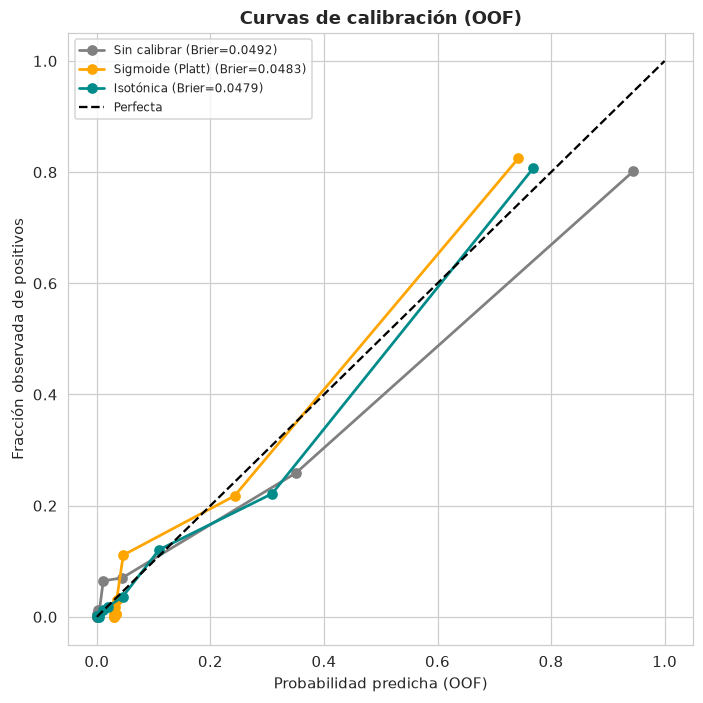

In [23]:
# Gráfico de calibración (reliability) sin calibrar vs sigmoide vs isotónica
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for probs, nombre, col in [(oof_uncal, 'Sin calibrar', 'gray'),
                           (oof_sig, 'Sigmoide (Platt)', 'orange'),
                           (oof_iso, 'Isotónica', LGBM_COLOR)]:
    fx, fy = calibration_curve(y_train, probs, n_bins=10, strategy='quantile')
    ax.plot(fy, fx, marker='o', lw=1.8, color=col,
            label=f'{nombre} (Brier={brier_score_loss(y_train, probs):.4f})')
ax.plot([0, 1], [0, 1], '--', color='black', label='Perfecta')
ax.set_xlabel('Probabilidad predicha (OOF)'); ax.set_ylabel('Fracción observada de positivos')
ax.set_title('Curvas de calibración (OOF)', fontweight='bold'); ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.savefig('outputs_sprint3/calibracion.png', bbox_inches='tight'); plt.show()

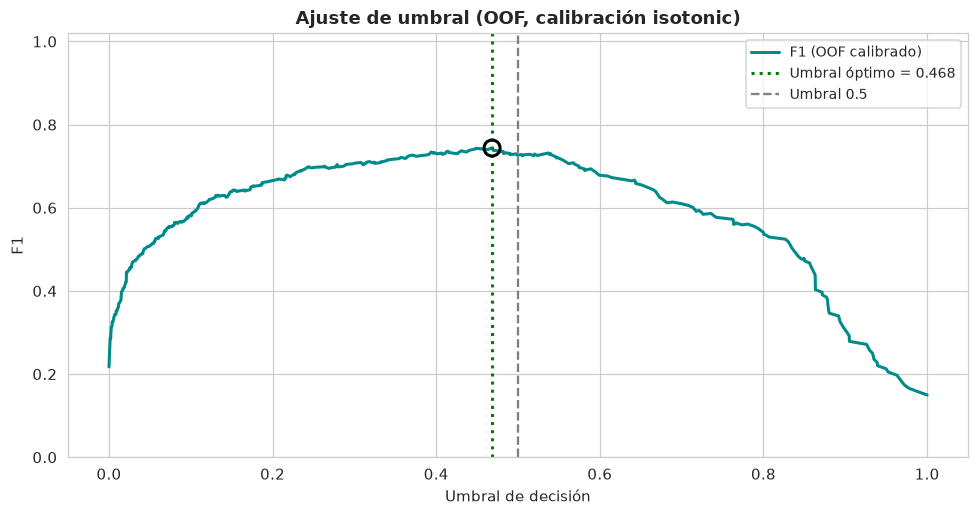

In [24]:
# Gráfico del ajuste de umbral (F1 vs umbral sobre OOF calibrado)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(thr, f1_grid[:-1], color=LGBM_COLOR, lw=2, label='F1 (OOF calibrado)')
ax.axvline(UMBRAL, ls=':', color='green', lw=2, label=f'Umbral óptimo = {UMBRAL:.3f}')
ax.axvline(0.5, ls='--', color='gray', label='Umbral 0.5')
ax.scatter([UMBRAL], [f1_umbral_oof], s=110, facecolors='none', edgecolors='black',
           linewidths=2, zorder=5)
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('F1'); ax.set_ylim(0, 1.02)
ax.set_title(f'Ajuste de umbral (OOF, calibración {CALIBRACION})', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('outputs_sprint3/ajuste_umbral.png', bbox_inches='tight'); plt.show()

In [25]:
# Pipeline final: calibrado, entrenado sobre TODO el training (set_S3)
modelo_final = CalibratedClassifierCV(make_pipe(PARAMS_S3), method=CALIBRACION, cv=5)
modelo_final.fit(X_S3_tr, y_train)

proba_ho = modelo_final.predict_proba(X_S3_te)[:, 1]
y_pred_ho = (proba_ho >= UMBRAL).astype(int)

metr = {
    'F1':        f1_score(y_test, y_pred_ho),
    'Precision': precision_score(y_test, y_pred_ho, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_ho),
    'AUC-ROC':   roc_auc_score(y_test, proba_ho),
    'AUC-PR':    average_precision_score(y_test, proba_ho),
    'Brier':     brier_score_loss(y_test, proba_ho),
}
print('Métricas HOLD-OUT (informativas):')
for k, v in metr.items():
    print(f'  {k:10s}: {v:.4f}')

Métricas HOLD-OUT (informativas):
  F1        : 0.7619
  Precision : 0.7547
  Recall    : 0.7692
  AUC-ROC   : 0.9607
  AUC-PR    : 0.8274
  Brier     : 0.0452


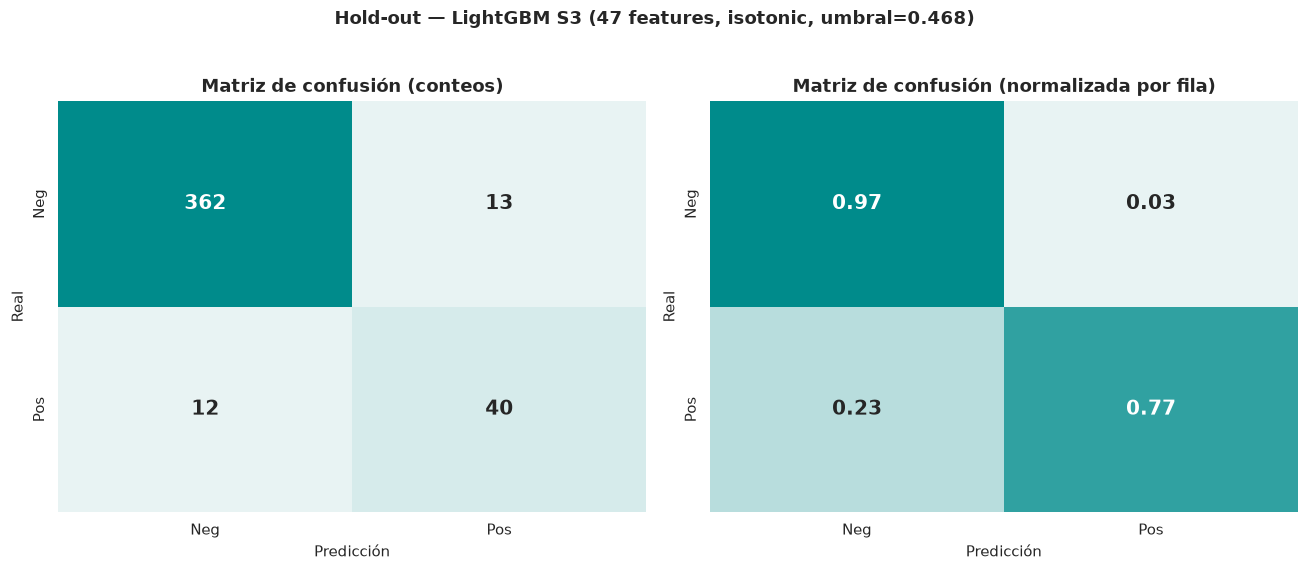

In [26]:
# Matriz de confusión (conteos y normalizada)
cm = confusion_matrix(y_test, y_pred_ho)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[0],
            cmap=sns.light_palette(LGBM_COLOR, as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[0].set_title('Matriz de confusión (conteos)', fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cbar=False, ax=axes[1],
            cmap=sns.light_palette(LGBM_COLOR, as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[1].set_title('Matriz de confusión (normalizada por fila)', fontweight='bold')
axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Real')
plt.suptitle(f'Hold-out — LightGBM S3 ({len(set_S3)} features, {CALIBRACION}, umbral={UMBRAL:.3f})',
             fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig('outputs_sprint3/final_matrices_confusion.png', bbox_inches='tight'); plt.show()

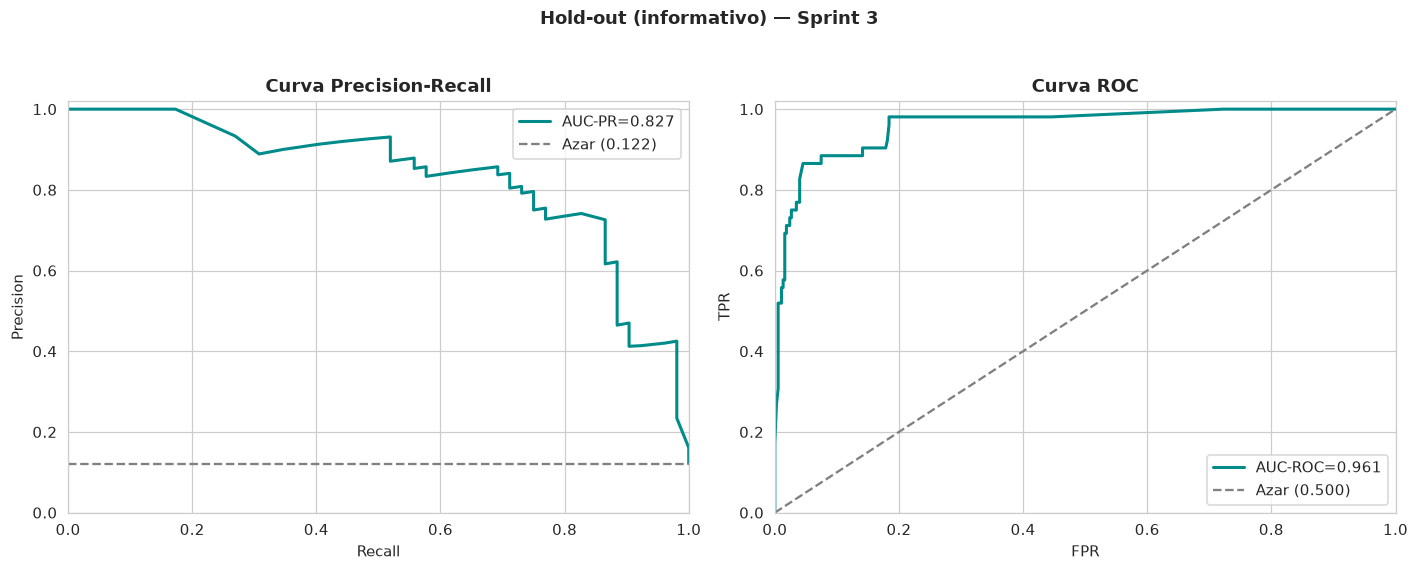

In [27]:
# Curvas Precision-Recall y ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
p, r, _ = precision_recall_curve(y_test, proba_ho)
axes[0].plot(r, p, color=LGBM_COLOR, lw=2, label=f'AUC-PR={metr["AUC-PR"]:.3f}')
axes[0].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].set_title('Curva Precision-Recall', fontweight='bold'); axes[0].legend()
fpr, tpr, _ = roc_curve(y_test, proba_ho)
axes[1].plot(fpr, tpr, color=LGBM_COLOR, lw=2, label=f'AUC-ROC={metr["AUC-ROC"]:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva ROC', fontweight='bold'); axes[1].legend(loc='lower right')
plt.suptitle('Hold-out (informativo) — Sprint 3', fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig('outputs_sprint3/final_curvas_pr_roc.png', bbox_inches='tight'); plt.show()

## Resumen

In [29]:
resumen3 = {
    'sprint': 3,
    'nombre': 'SHAP + selección (1-SE), curvas de aprendizaje, re-Optuna y calibración',
    'protocolo': 'Decisión por F1_CV/OOF; hold-out una sola vez (informativo).',
    'modelo_base': 'LightGBM',
    'balanceo': BALANCEO,
    'set_partida_s2': 'E5 +FE +Cluster LOG',
    'n_features_s2': len(FEATURES_S2),
    # --- Paso 1: selección ---
    'criterio_shap_acumulado': UMBRAL_ACUM,
    'n_features_95shap': int(n_95),
    'regla_seleccion': '1-SE sobre barrido CV',
    'n_features_s3': int(n_opt),
    'set_s3_features': set_S3,
    'f1_cv_s3_params_fijos': round(f1_s3_fijo, 4),
    # --- Paso 3: hiperparámetros ---
    'params_s2': PARAMS_S2,
    'params_s3': PARAMS_S3,
    'origen_params_s3': origen_params,
    'f1_cv_optuna_s3': round(f1_opt, 4),
    # --- Diagnóstico bias/varianza (Paso 2 vs Paso 3b) ---
    'gap_train_val': {
        'paso2_params_fijos_s2': round(gap_pre, 4),
        'paso3b_params_optuna_s3': round(gap_post, 4),
        'reduccion_gap': round(delta_gap, 4),
    },
    # --- Paso 4: calibración + umbral ---
    'calibracion': CALIBRACION,
    'brier_oof': {k: round(v, 5) for k, v in brier.items()},
    'umbral': round(UMBRAL, 4),
    'f1_oof_umbral': round(f1_umbral_oof, 4),
    # --- decisión y evolución ---
    'f1_final': round(f1_s3, 4),
    'f1_sprint2': round(F1_SPRINT2, 4),
    'mejora_vs_sprint2': round(f1_s3 - F1_SPRINT2, 4),
    # --- hold-out (informativo) ---
    'metricas_finales': {k: round(v, 4) for k, v in metr.items()},
}
with open('outputs_sprint3/final_resumen_sprint3.json', 'w') as f:
    json.dump(resumen3, f, indent=2, ensure_ascii=False)

print('════════════════════ RESUMEN SPRINT 3 ════════════════════')
print(f'Selección: {len(FEATURES_S2)} features → 95% |SHAP| = {n_95} → 1-SE = {n_opt} features')
print(f'Hiperparámetros: {origen_params}')
print(f'Calibración: {CALIBRACION} | Umbral: {UMBRAL:.4f}')
print(f'\nF1_CV Sprint 3 (decisión): {coral(f"{f1_s3:.4f}")}')
print(f'   F1 hold-out (informativo): {metr["F1"]:.4f}')
print(f'\nEvolución del proyecto (por F1_CV):')
print(f'   Sprint 0 = 0.7090')
print(f'   Sprint 1 = 0.7277 (+0.0187)')
print(f'   Sprint 2 = {F1_SPRINT2:.4f} (+{F1_SPRINT2-0.7277:+.4f})'.replace('++', '+'))
print(f'   Sprint 3 = {f1_s3:.4f} ({f1_s3-F1_SPRINT2:+.4f})')
print(f'\nFeatures: {len(FEATURES_S2)} (S2) → {n_opt} (S3), reducción del '
      f'{100*(1-n_opt/len(FEATURES_S2)):.0f}%')
print('\nSiguiente (Sprint 4): análisis de errores, slices y estrategias de mitigación.')

════════════════════ RESUMEN SPRINT 3 ════════════════════
Selección: 144 features → 95% |SHAP| = 101 → 1-SE = 47 features
Hiperparámetros: Optuna S3
Calibración: isotonic | Umbral: 0.4683

F1_CV Sprint 3 (decisión): 0.7706
   F1 hold-out (informativo): 0.7619

Evolución del proyecto (por F1_CV):
   Sprint 0 = 0.7090
   Sprint 1 = 0.7277 (+0.0187)
   Sprint 2 = 0.7540 (+0.0263)
   Sprint 3 = 0.7706 (+0.0166)

Features: 144 (S2) → 47 (S3), reducción del 67%

Siguiente (Sprint 4): análisis de errores, slices y estrategias de mitigación.
